# Decision Tree Exploration — Telco Customer Churn

This notebook explores a **Decision Tree** classifier for predicting customer churn,
covering: data prep, a baseline (unconstrained) tree, overfitting diagnosis,
hyperparameter tuning, pruning, tree visualization, and feature importance.

Dataset: `Telco_Cusomer_Churn.csv` (7,043 customers, 21 columns).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    roc_curve, roc_auc_score
)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42

## 1. Load and inspect the data

In [2]:
df = pd.read_csv("/Telco_Cusomer_Churn.csv")
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


**Known issue in this dataset:** `TotalCharges` is loaded as an object/string
column because 11 rows have blank strings (new customers with `tenure == 0`).
We convert it to numeric and drop those rows (they have no churn history yet
to learn from anyway).

In [4]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Rows with missing TotalCharges:", df["TotalCharges"].isna().sum())
df = df.dropna(subset=["TotalCharges"]).reset_index(drop=True)

# customerID is just an identifier, not a feature
df = df.drop(columns=["customerID"])
print(df.shape)

Rows with missing TotalCharges: 11
(7032, 20)


## 2. Target class balance

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


/tmp/ipykernel_423/1240436977.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Churn", palette=["#1f77b4", "#d62728"])


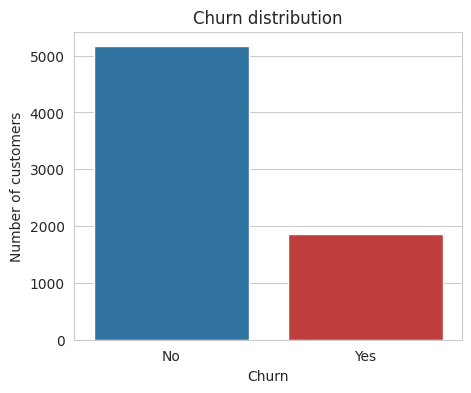

In [5]:
churn_counts = df["Churn"].value_counts(normalize=True) * 100
print(churn_counts)

plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="Churn", palette=["#1f77b4", "#d62728"])
plt.title("Churn distribution")
plt.ylabel("Number of customers")
plt.show()

The classes are imbalanced (~73% No / ~27% Yes). This matters for a
Decision Tree because, left unconstrained, it can still reach high overall
accuracy while doing a poor job of catching actual churners. We'll use
`class_weight="balanced"` and look at **F1 / recall on the "Churn" class**,
not just accuracy.

## 3. Preprocessing

Trees don't need feature scaling (they split on raw thresholds per feature),
but categorical columns still need to be numeric. We'll one-hot encode
categoricals and label-encode the binary target.

In [6]:
target = "Churn"
y = LabelEncoder().fit_transform(df[target])  # No -> 0, Yes -> 1

X = df.drop(columns=[target])
categorical_cols = X.select_dtypes(include="object").columns.tolist()
print("Categorical columns:", categorical_cols)

X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
print("Feature matrix shape after encoding:", X_encoded.shape)

Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Feature matrix shape after encoding: (7032, 30)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")
print(f"Train churn rate: {y_train.mean():.2%} | Test churn rate: {y_test.mean():.2%}")

Train: 5625 rows | Test: 1407 rows
Train churn rate: 26.58% | Test churn rate: 26.58%


## 4. Baseline Decision Tree (unconstrained)

First, fit a tree with no depth limit to see what happens when we let it
grow freely. This is the classic overfitting demonstration for trees.

In [8]:
baseline_tree = DecisionTreeClassifier(random_state=RANDOM_STATE)
baseline_tree.fit(X_train, y_train)

train_acc = baseline_tree.score(X_train, y_train)
test_acc = baseline_tree.score(X_test, y_test)

print(f"Unconstrained tree depth: {baseline_tree.get_depth()}, leaves: {baseline_tree.get_n_leaves()}")
print(f"Train accuracy: {train_acc:.4f}")
print(f"Test accuracy:  {test_acc:.4f}")
print(f"Gap (train - test): {train_acc - test_acc:.4f}  <- large gap = overfitting")

Unconstrained tree depth: 23, leaves: 1112
Train accuracy: 0.9988
Test accuracy:  0.7186
Gap (train - test): 0.2802  <- large gap = overfitting


A large train/test accuracy gap here is the signature of overfitting — the tree has memorized noise in the training set. The next sections fix this with depth limits, pruning, and proper tuning.

## 5. How `max_depth` controls overfitting

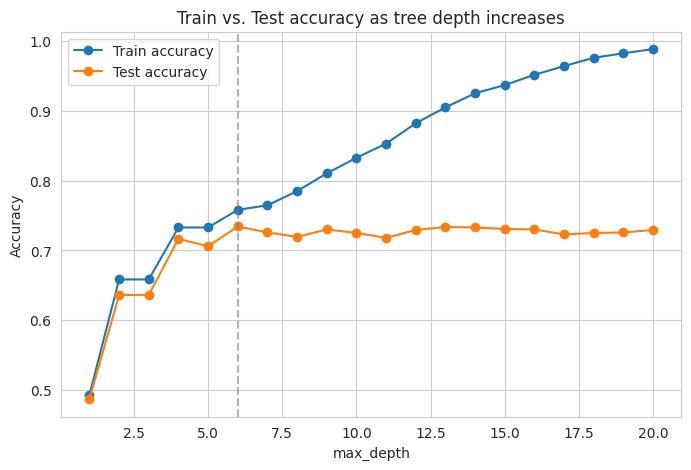

Depth with best test accuracy: 6


In [9]:
depths = range(1, 21)
train_scores, test_scores = [], []

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, class_weight="balanced", random_state=RANDOM_STATE)
    clf.fit(X_train, y_train)
    train_scores.append(clf.score(X_train, y_train))
    test_scores.append(clf.score(X_test, y_test))

plt.figure(figsize=(8, 5))
plt.plot(depths, train_scores, marker="o", label="Train accuracy")
plt.plot(depths, test_scores, marker="o", label="Test accuracy")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Train vs. Test accuracy as tree depth increases")
plt.legend()
plt.axvline(depths[int(np.argmax(test_scores))], color="gray", linestyle="--", alpha=0.6,
            label="Best test-accuracy depth")
plt.show()

best_depth = depths[int(np.argmax(test_scores))]
print(f"Depth with best test accuracy: {best_depth}")

Train accuracy keeps climbing (or plateaus near 1.0) as depth increases, while test accuracy peaks early and then flattens or degrades slightly. The gap between the two curves widening is overfitting in action.

## 6. Cost-complexity pruning path

Instead of only capping depth, scikit-learn can compute the sequence of
`ccp_alpha` values that correspond to successively more pruned trees. This
gives a principled way to choose a pruning strength rather than guessing.

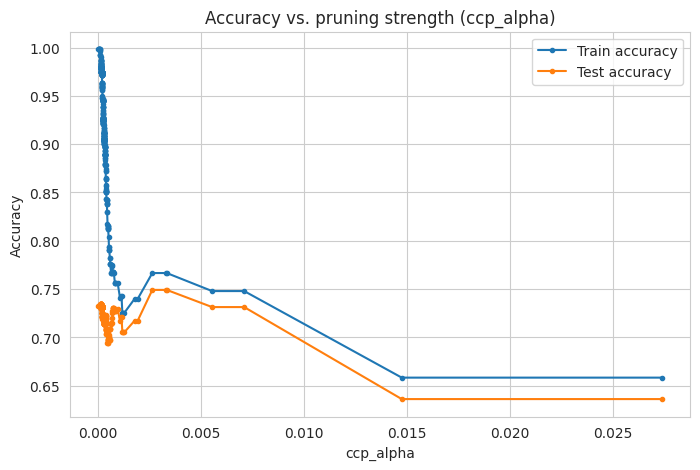

In [10]:
path = DecisionTreeClassifier(random_state=RANDOM_STATE).cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

# Skip the very last alpha (it collapses the tree to a single root node)
ccp_alphas = ccp_alphas[:-1]

train_scores_ccp, test_scores_ccp = [], []
for alpha in ccp_alphas:
    clf = DecisionTreeClassifier(ccp_alpha=alpha, class_weight="balanced", random_state=RANDOM_STATE)
    clf.fit(X_train, y_train)
    train_scores_ccp.append(clf.score(X_train, y_train))
    test_scores_ccp.append(clf.score(X_test, y_test))

plt.figure(figsize=(8, 5))
plt.plot(ccp_alphas, train_scores_ccp, marker=".", label="Train accuracy")
plt.plot(ccp_alphas, test_scores_ccp, marker=".", label="Test accuracy")
plt.xlabel("ccp_alpha")
plt.ylabel("Accuracy")
plt.title("Accuracy vs. pruning strength (ccp_alpha)")
plt.legend()
plt.show()

## 7. Hyperparameter tuning with GridSearchCV

Now do a proper 5-fold grid search over the key parameters, scoring on F1
(better than accuracy for imbalanced classes) with `class_weight="balanced"`
to compensate for the ~73/27 split.

In [11]:
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 7, 10, 15, None],
    "min_samples_split": [2, 10, 20],
    "min_samples_leaf": [1, 5, 10],
}

base_model = DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE)

grid = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1,
)
grid.fit(X_train, y_train)

best_tree = grid.best_estimator_
print("Best params:", grid.best_params_)
print(f"Best CV F1: {grid.best_score_:.4f}")
print(f"Tuned tree depth: {best_tree.get_depth()}, leaves: {best_tree.get_n_leaves()}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best params: {'criterion': 'gini', 'max_depth': 7, 'min_samples_leaf': 10, 'min_samples_split': 2}
Best CV F1: 0.6188
Tuned tree depth: 7, leaves: 79


## 8. Evaluate the tuned tree on the test set

In [13]:
y_pred = best_tree.predict(X_test)
y_proba = best_tree.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))

print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1:        {f1_score(y_test, y_pred):.4f}")
print(f"ROC AUC:   {roc_auc_score(y_test, y_proba):.4f}")

              precision    recall  f1-score   support

    No Churn       0.91      0.69      0.79      1033
       Churn       0.49      0.81      0.61       374

    accuracy                           0.72      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.72      0.74      1407

Accuracy:  0.7228
Precision: 0.4872
Recall:    0.8128
F1:        0.6092
ROC AUC:   0.8253


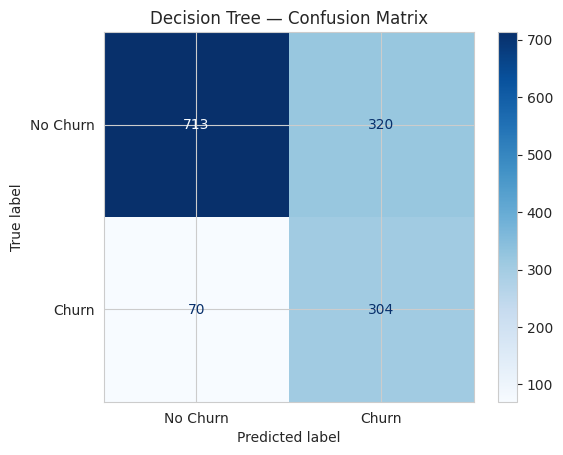

In [14]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Churn", "Churn"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Decision Tree — Confusion Matrix")
plt.show()

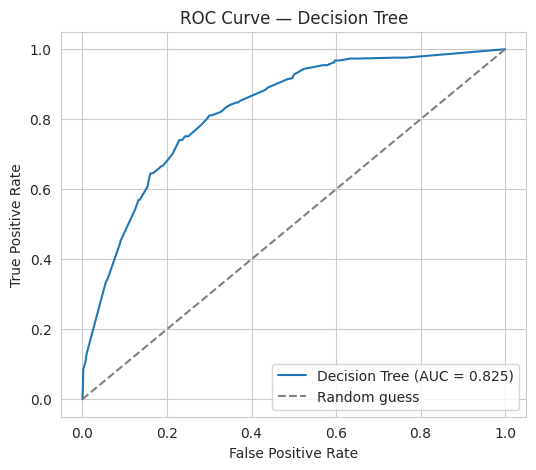

In [15]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Decision Tree (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Decision Tree")
plt.legend()
plt.show()

## 9. Visualize the tree's decision logic

The full tuned tree is usually too deep to read, so we plot only the top
levels — this is the main interpretability advantage a tree has over KNN.

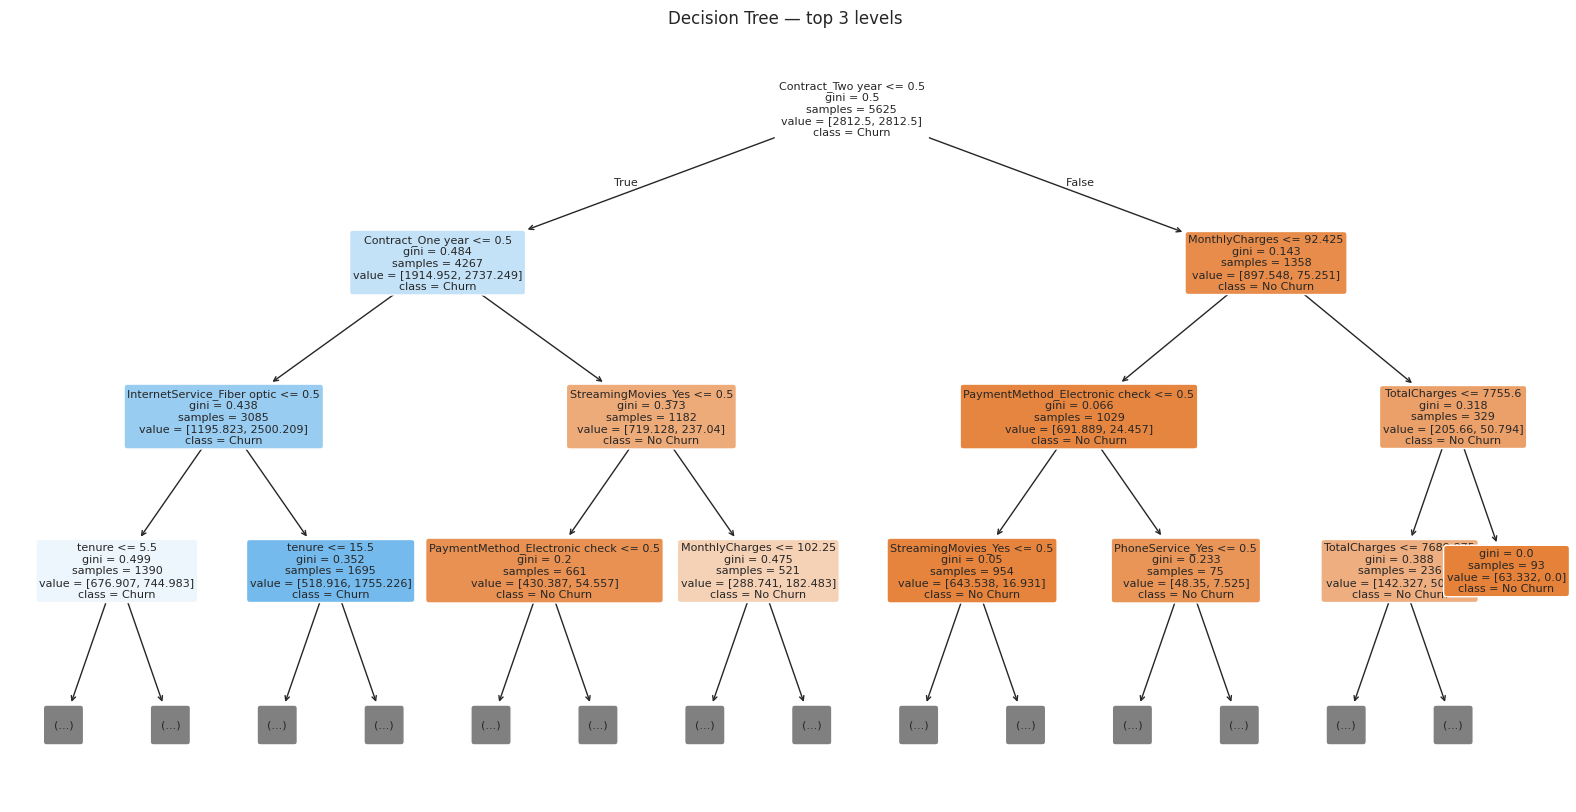

In [16]:
plt.figure(figsize=(20, 10))
plot_tree(
    best_tree,
    max_depth=3,
    feature_names=X_encoded.columns.tolist(),
    class_names=["No Churn", "Churn"],
    filled=True,
    rounded=True,
    fontsize=8,
)
plt.title("Decision Tree — top 3 levels")
plt.show()

## 10. Feature importance

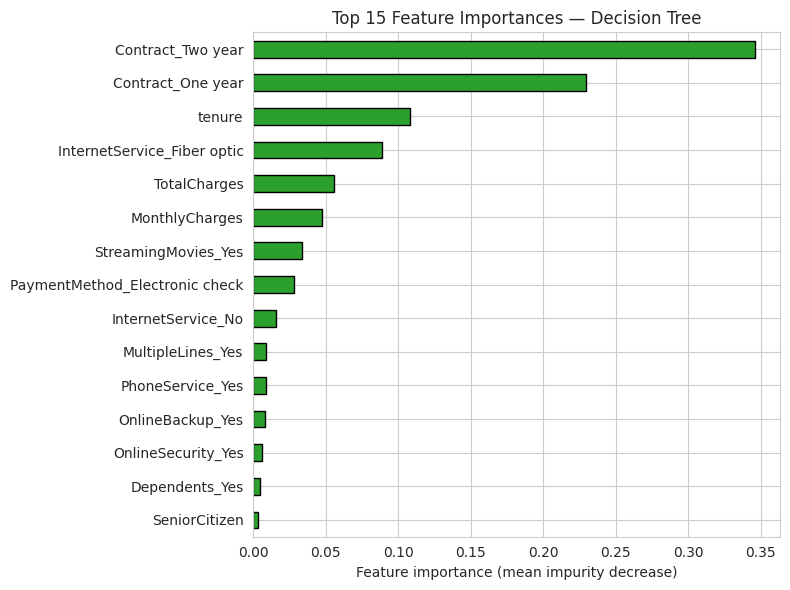

,0
Contract_Two year,0.346010
Contract_One year,0.229756
tenure,0.108309
InternetService_Fiber optic,0.088528
TotalCharges,0.055966
MonthlyCharges,0.047583
StreamingMovies_Yes,0.033668
PaymentMethod_Electronic check,0.028148
InternetService_No,0.015506
MultipleLines_Yes,0.008773


In [17]:
importances = pd.Series(best_tree.feature_importances_, index=X_encoded.columns)
top_importances = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
top_importances[::-1].plot(kind="barh", color="#2ca02c", edgecolor="black")
plt.xlabel("Feature importance (mean impurity decrease)")
plt.title("Top 15 Feature Importances — Decision Tree")
plt.tight_layout()
plt.show()

top_importances

Note: unlike Logistic Regression coefficients, these importances are
always non-negative — they tell you *how much* a feature contributed to
splitting decisions, not *which direction* it pushes predictions. Cross-check
direction by reading the top-level splits in the tree diagram above.

## 11. Summary

- The **unconstrained** tree overfits badly (large train/test accuracy gap).
- **`max_depth`** and **cost-complexity pruning (`ccp_alpha`)** are the two
  main levers to fix that; the grid search combined both with
  `min_samples_split` / `min_samples_leaf`.
- The **tuned** tree's test-set metrics (precision/recall/F1/AUC) are printed
  above — copy these into your model comparison table alongside KNN and
  Logistic Regression.
- The tree diagram and feature importances give you a directly readable
  explanation of *why* the model predicts churn for a given customer, which
  is worth discussing in the report as this model's key strength over KNN.